# Creative Diversity and TikTok Ad Performance
## Reproducibility Notebook — CTR Analysis with OLS + Random Forest + SHAP

**Metodología:**
1. Setup e imports
2. Carga y preprocesamiento de datos
3. Análisis exploratorio
4. OLS: validación de supuestos + 5-fold cross-validation
5. Random Forest: 5-fold cross-validation + SHAP
6. Comparación entre modelos

**Referencias:**
- Breiman, L. (2001). Statistical Modeling: The Two Cultures. *Statistical Science*, 16(3), 199–231.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS*.


## 1. Setup e Imports

In [3]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="pastel")

# OLS — statsmodels
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

# Cross-validation y modelos sklearn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

# SHAP
import shap

# Stats
from scipy import stats
from scipy.stats import spearmanr

print("✓ Todas las librerías cargadas correctamente.")


✓ Todas las librerías cargadas correctamente.


## 2. Carga, Preprocesamiento y Transformacion de Datos

In [4]:
df = pd.read_csv("../../data/datasets/tiktok_topads_clean.csv")
print("Shape original:", df.shape)
print("\nNulls por columna:")
print(df.isna().sum()[df.isna().sum() > 0])


Shape original: (578, 21)

Nulls por columna:
ad_title              1
brand_name          129
creative_concept     96
talent_type         227
dtype: int64


### CTR 
El Click Through Rate es nuestra variable objetivo, la que queremos explicar. 

Violacion de supuestos OLS:
- Se puede observar en el analisis de distribucion de la misma, que es fuertemente asimetrica por derecha. Esto representa un problema, que viola los supestos de OLS, ya que la forma de esta distribucion va a influir furtemente en la distribucion de los residuos, estos no van a estar normalmente distribuidos Fox (2016, Cap 5).
- Fox (2016, Cap 12) propone como solucion a este problema una serie de transformaciones de la familia Box-Cox a la variable target. En este caso aplicamos logaritmo al target. 

<Axes: title={'center': "Dsitribucion de la variable dependiente 'CTR': Se observa que es asimetrica por derecha"}, ylabel='Frequency'>

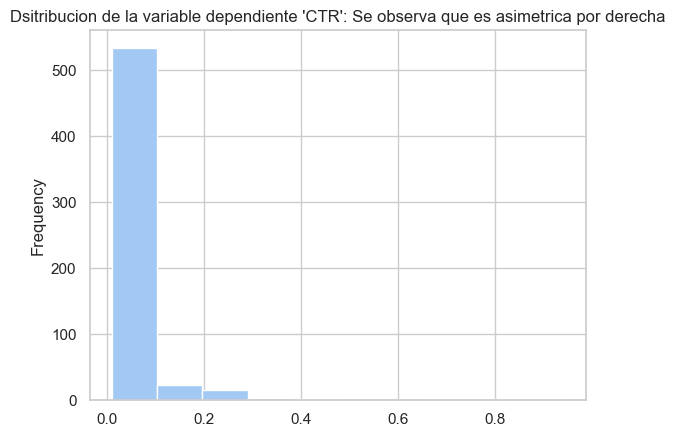

In [9]:
df['ctr'].plot(kind='hist', title="Dsitribucion de la variable dependiente 'CTR': Se observa que es asimetrica por derecha")

In [5]:
# ── Tratamiento de nulos ──────────────────────────────────────────────────
# talent_type: null = ausencia real de talento en el ad (no es dato faltante)
df['talent_type'] = df['talent_type'].fillna('No Talent')

# creative_concept: null = no aplica para ese formato creativo
df['creative_concept'] = df['creative_concept'].fillna('Not Applicable')

# ── Transformación logarítmica del CTR ────────────────────────────────────
# Justificación: CTR tiene distribución fuertemente sesgada a la derecha
# (skewness >> 0). log(CTR) estabiliza la varianza y acerca la distribución
# a la normalidad, mejorando el cumplimiento de supuestos de OLS.
# Todos los valores de CTR son > 0 (mínimo = 0.01), por lo que log es directo.
df['log_ctr'] = np.log(df['ctr'])

print("Preprocesamiento completado.")
print(f"\nSkewness CTR original: {df['ctr'].skew():.3f}")
print(f"Skewness log(CTR):     {df['log_ctr'].skew():.3f}")
print("\nEstadísticas de log(CTR):")
print(df['log_ctr'].describe().round(4))


Preprocesamiento completado.

Skewness CTR original: 6.782
Skewness log(CTR):     1.872

Estadísticas de log(CTR):
count    578.0000
mean      -4.0853
std        0.9298
min       -4.6052
25%       -4.6052
50%       -4.6052
75%       -3.9120
max       -0.0619
Name: log_ctr, dtype: float64


<Axes: ylabel='Frequency'>

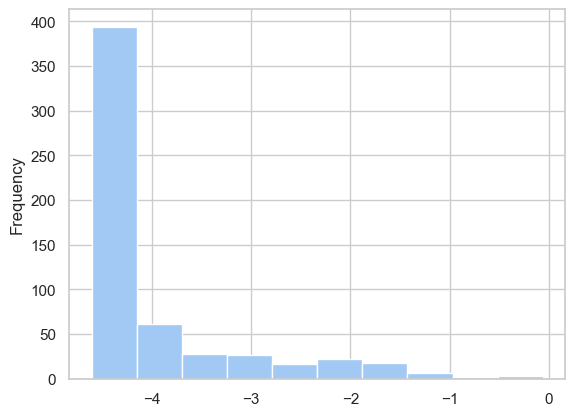

In [6]:
df['log_ctr'].plot(kind='hist')

## 3. Análisis Exploratorio

In [ ]:
# ── Distribución CTR: original vs log ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['ctr'], bins=40, color='skyblue', edgecolor='white')
axes[0].axvline(df['ctr'].mean(), color='red', linestyle='--',
                label=f"Media = {df['ctr'].mean():.3f}")
axes[0].set_title("Distribución de CTR (original)")
axes[0].set_xlabel("CTR"); axes[0].set_ylabel("Frecuencia"); axes[0].legend()

axes[1].hist(df['log_ctr'], bins=40, color='salmon', edgecolor='white')
axes[1].axvline(df['log_ctr'].mean(), color='red', linestyle='--',
                label=f"Media = {df['log_ctr'].mean():.3f}")
axes[1].set_title("Distribución de log(CTR)")
axes[1].set_xlabel("log(CTR)"); axes[1].set_ylabel("Frecuencia"); axes[1].legend()

plt.tight_layout()
plt.savefig("ctr_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── CTR medio por dimensión creativa ─────────────────────────────────────
creative_dims = ['creative_theme', 'creative_concept', 'talent_type']
fig, axes = plt.subplots(3, 1, figsize=(10, 14))

for ax, dim in zip(axes, creative_dims):
    means  = df.groupby(dim)['ctr'].mean().sort_values(ascending=False)
    counts = df[dim].value_counts()[means.index]
    bars   = ax.barh(means.index, means.values, color='steelblue', alpha=0.75)
    ax.set_xlabel("CTR medio")
    ax.set_title(f"CTR medio por {dim.replace('_', ' ').title()}")
    for bar, (cat, n) in zip(bars, counts.items()):
        ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                f"n={n}", va='center', fontsize=8)

plt.tight_layout()
plt.savefig("ctr_by_dimension.png", dpi=150, bbox_inches='tight')
plt.show()


## 4. Regresión OLS

Se utiliza **codificación de efectos** (Sum contrasts) para que cada coeficiente
refleje la desviación de esa categoría respecto a la **gran media global**,
no respecto a una categoría de referencia arbitraria. Esto es apropiado para
comparar dimensiones creativas de forma simétrica.

Se aplican **errores estándar robustos HC1** para corregir heterocedasticidad.

Variables de control incluidas: duración del video, objetivo de la campaña,
tipo de objetivo de conversión.


In [ ]:
# ── Estandarización ──────────────────────────────────────────────────────
df_ols = df.copy()
df_ols['z_log_ctr']  = (df_ols['log_ctr']  - df_ols['log_ctr'].mean())  / df_ols['log_ctr'].std()
df_ols['z_duration'] = (df_ols['duration']  - df_ols['duration'].mean()) / df_ols['duration'].std()

cats = ['creative_theme','creative_concept','talent_type','objective_value','campaign_objective']
for v in cats:
    df_ols[v] = pd.Categorical(df_ols[v], categories=sorted(df_ols[v].dropna().unique()))

# ── Modelo OLS con efectos coding ─────────────────────────────────────────
formula = (
    "z_log_ctr ~ z_duration + "
    "C(creative_theme, Sum) + C(creative_concept, Sum) + C(talent_type, Sum) + "
    "C(objective_value, Sum) + C(campaign_objective, Sum)"
)

ols_model = smf.ols(formula, data=df_ols).fit(cov_type='HC1')
print(ols_model.summary())


In [ ]:
# ── ANOVA Tipo II: significancia conjunta por dimensión ──────────────────
# Importante: muestra si CADA dimensión como conjunto tiene poder explicativo
print("ANOVA Tipo II — significancia conjunta por dimensión:")
print(anova_lm(ols_model, typ=2).round(4))


### 4.1 Validación de Supuestos OLS

Supuestos a verificar:
1. **Normalidad de residuos** — Q-Q plot + test Shapiro-Wilk
2. **Homocedasticidad** — Residuos vs. fitted + test Breusch-Pagan
3. **Ausencia de autocorrelación** — Test Durbin-Watson (valor ideal ≈ 2.0)


In [ ]:
residuals = ols_model.resid
fitted    = ols_model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Residuos vs Fitted
axes[0,0].scatter(fitted, residuals, alpha=0.4, color='steelblue', s=20)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel("Valores ajustados"); axes[0,0].set_ylabel("Residuos")
axes[0,0].set_title("Residuos vs. Valores Ajustados")

# 2. Q-Q Plot
sm.qqplot(residuals, line='s', ax=axes[0,1], alpha=0.5)
axes[0,1].set_title("Q-Q Plot de Residuos")

# 3. Histograma de residuos
axes[1,0].hist(residuals, bins=40, color='salmon', edgecolor='white')
axes[1,0].set_xlabel("Residuos"); axes[1,0].set_ylabel("Frecuencia")
axes[1,0].set_title("Distribución de Residuos")

# 4. Scale-Location
std_resid = residuals / residuals.std()
axes[1,1].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.4, color='steelblue', s=20)
axes[1,1].set_xlabel("Valores ajustados")
axes[1,1].set_ylabel("√|Residuos estandarizados|")
axes[1,1].set_title("Scale-Location (Homocedasticidad)")

plt.tight_layout()
plt.savefig("ols_assumptions.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Tests estadísticos ────────────────────────────────────────────────────
stat_sw, p_sw = stats.shapiro(residuals.sample(min(200, len(residuals)), random_state=42))
bp_lm, bp_pval, _, _ = het_breuschpagan(residuals, ols_model.model.exog)
dw = durbin_watson(residuals)

print("=" * 55)
print("TESTS DE SUPUESTOS OLS")
print("=" * 55)
print(f"Shapiro-Wilk (normalidad):      W={stat_sw:.4f}, p={p_sw:.4f}")
r1 = '✓ No se rechaza normalidad' if p_sw > 0.05 else '✗ Se rechaza normalidad'
print(f"  → {r1}")

print(f"\nBreusch-Pagan (homocedasticidad): LM={bp_lm:.4f}, p={bp_pval:.4f}")
r2 = '✓ No se rechaza homocedasticidad' if bp_pval > 0.05 else '✗ Heterocedasticidad — errores HC1 aplicados (correcto)'
print(f"  → {r2}")

print(f"\nDurbin-Watson (autocorrelación):  DW={dw:.4f}")
if 1.5 < dw < 2.5:
    r3 = '✓ Sin autocorrelación significativa'
else:
    r3 = '⚠ Posible autocorrelación — puede indicar clustering intra-marca'
print(f"  → {r3}")
print("\nNota: Si DW < 1.5, mencionar como limitación (posible clustering")
print("por marca o agrupamiento temporal en los datos).")


### 4.2 Cross-Validation OLS (k=5)

Siguiendo a Breiman (2001), la bondad de ajuste in-sample no es suficiente para
evaluar un modelo. El R² out-of-sample, estimado via 5-fold CV, refleja la
capacidad predictiva real sobre datos no vistos durante el entrenamiento.


In [ ]:
features_cv = ['creative_theme','creative_concept','talent_type',
               'objective_value','campaign_objective','duration']

# get_dummies con drop_first=True evita multicolinealidad perfecta (necesario para sklearn)
X_cv = pd.get_dummies(df[features_cv], drop_first=True).astype(float)
y_cv = df['log_ctr'].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_ols = cross_validate(
    LinearRegression(), X_cv, y_cv, cv=kf,
    scoring=['r2', 'neg_root_mean_squared_error'],
    return_train_score=True
)

print("=" * 55)
print("OLS — 5-Fold Cross-Validation")
print("=" * 55)
print(f"R² in-sample  (train): {cv_ols['train_r2'].mean():.4f} ± {cv_ols['train_r2'].std():.4f}")
print(f"R² out-of-sample (CV): {cv_ols['test_r2'].mean():.4f} ± {cv_ols['test_r2'].std():.4f}")
print(f"RMSE out-of-sample:    {-cv_ols['test_neg_root_mean_squared_error'].mean():.4f}")
print(f"\nR² por fold: {np.round(cv_ols['test_r2'], 4)}")
print(f"\nDiferencia in/out-of-sample: {cv_ols['train_r2'].mean() - cv_ols['test_r2'].mean():.4f}")
print("(diferencia pequeña = bajo sobreajuste)")


In [ ]:
# ── Forest plot: coeficientes OLS de dimensiones creativas ───────────────
params = ols_model.params
conf   = ols_model.conf_int()
pvals  = ols_model.pvalues

coef_df = pd.DataFrame({
    'coef':  params,
    'lower': conf[0],
    'upper': conf[1],
    'pval':  pvals
}).reset_index().rename(columns={'index': 'term'})

# Filtrar solo dimensiones creativas
excluir = ['Intercept', 'z_duration', 'C(objective_value', 'C(campaign_objective']
mask = ~coef_df['term'].apply(lambda t: any(t.startswith(e) for e in excluir))
coef_creative = coef_df[mask].sort_values('coef')

colors = ['#e74c3c' if p < 0.05 else '#bdc3c7' for p in coef_creative['pval']]

plt.figure(figsize=(8, max(6, len(coef_creative) * 0.28)))
for i, (_, row) in enumerate(coef_creative.iterrows()):
    plt.hlines(i, row['lower'], row['upper'], color=colors[i], linewidth=1.5)
    plt.plot(row['coef'], i, 'o', color=colors[i], markersize=5)

plt.yticks(range(len(coef_creative)), coef_creative['term'], fontsize=8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel("Coeficiente estandarizado (log CTR)")
plt.title("OLS — Coeficientes de Dimensiones Creativas\n(rojo = p<0.05  |  gris = no significativo)")
plt.tight_layout()
plt.savefig("ols_forest_plot.png", dpi=150, bbox_inches='tight')
plt.show()


## 5. Random Forest

Random Forest no impone forma funcional sobre los datos (Breiman, 2001).
Captura interacciones no lineales entre dimensiones sin que el investigador
las especifique explícitamente.

Se reportan:
- **5-fold cross-validation**: R² out-of-sample comparable con OLS
- **SHAP values**: importancia por observación individual, basada en teoría de juegos (Lundberg & Lee, 2017)

> Nota: SHAP es más honesto que el impurity-based feature importance de sklearn,
> especialmente para variables categóricas con muchas categorías, ya que no tiene
> sesgo hacia variables con más niveles.


In [ ]:
# ── Dataset para RF (sin drop_first — RF no tiene problema con multicolinealidad) ──
features_rf = ['creative_theme','creative_concept','talent_type',
               'objective_value','campaign_objective','duration']

X_rf = pd.get_dummies(df[features_rf], drop_first=False).astype(float)
y_rf = df['log_ctr'].values

print(f"Features en RF: {X_rf.shape[1]} columnas (tras dummies)")
print(f"Observaciones:  {X_rf.shape[0]}")


In [ ]:
# ── 5-Fold CV Random Forest ───────────────────────────────────────────────
# n_estimators=200, max_depth=10: buen balance entre capacidad y velocidad
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)

cv_rf = cross_validate(
    rf, X_rf, y_rf, cv=kf,
    scoring=['r2', 'neg_root_mean_squared_error'],
    return_train_score=True
)

print("=" * 55)
print("Random Forest — 5-Fold Cross-Validation")
print("=" * 55)
print(f"R² in-sample  (train): {cv_rf['train_r2'].mean():.4f} ± {cv_rf['train_r2'].std():.4f}")
print(f"R² out-of-sample (CV): {cv_rf['test_r2'].mean():.4f} ± {cv_rf['test_r2'].std():.4f}")
print(f"RMSE out-of-sample:    {-cv_rf['test_neg_root_mean_squared_error'].mean():.4f}")
print(f"\nR² por fold: {np.round(cv_rf['test_r2'], 4)}")
print(f"\nDiferencia in/out-of-sample: {cv_rf['train_r2'].mean() - cv_rf['test_r2'].mean():.4f}")
print("(diferencia grande = sobreajuste — ver comparación con OLS abajo)")


In [ ]:
# ── Entrenar RF sobre dataset completo (para SHAP) ───────────────────────
rf_full = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_full.fit(X_rf, y_rf)
print("RF entrenado sobre dataset completo.")
print(f"R² in-sample: {rf_full.score(X_rf, y_rf):.4f}")


### 5.1 Análisis SHAP

SHAP calcula para **cada observación individual** cuánto contribuyó cada variable
a la predicción del modelo, usando la teoría de valores de Shapley de juegos cooperativos.

A diferencia del feature importance promedio, SHAP:
- Muestra la **dirección** del efecto (positivo o negativo sobre CTR)
- Respeta interacciones entre variables
- Permite agregar importancias a nivel de dimensión de forma honesta


In [ ]:
# ── Calcular SHAP values ─────────────────────────────────────────────────
explainer   = shap.TreeExplainer(rf_full)
shap_values = explainer.shap_values(X_rf)

print(f"SHAP values calculados.")
print(f"Shape: {shap_values.shape}  (filas=observaciones, columnas=features)")


In [ ]:
# ── SHAP Summary Plot (Beeswarm) — Top 20 features ───────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_rf, show=False, max_display=20)
plt.title("SHAP Summary Plot — Top 20 features\n(cada punto = una campaña)")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Agregar |SHAP| por dimensión ─────────────────────────────────────────
def assign_dimension(feature_name):
    for dim in ['creative_theme','creative_concept','talent_type',
                'objective_value','campaign_objective']:
        if feature_name.startswith(dim):
            return dim
    return 'duration'

shap_mean_abs = np.abs(shap_values).mean(axis=0)
shap_dim_df = pd.DataFrame({
    'feature':       X_rf.columns,
    'mean_abs_shap': shap_mean_abs
})
shap_dim_df['dimension'] = shap_dim_df['feature'].apply(assign_dimension)
shap_by_dim = shap_dim_df.groupby('dimension')['mean_abs_shap'].sum().sort_values(ascending=False)

print("Mean |SHAP value| por dimensión:")
print(shap_by_dim.round(4))

# Plot
creative_list = ['creative_theme', 'creative_concept', 'talent_type']
colors_shap = ['#e74c3c' if d in creative_list else '#bdc3c7' for d in shap_by_dim.index]

plt.figure(figsize=(8, 5))
plt.barh(shap_by_dim.index, shap_by_dim.values, color=colors_shap, alpha=0.85)
plt.xlabel("Mean |SHAP value| (suma sobre categorías)")
plt.title("SHAP — Importancia por Dimensión\n(rojo = dimensiones creativas  |  gris = controles)")
plt.tight_layout()
plt.savefig("shap_by_dimension.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── SHAP: Top feature por dimensión creativa ─────────────────────────────
print("Top feature (mayor |SHAP| promedio) dentro de cada dimensión creativa:\n")
for dim in creative_list:
    top = (shap_dim_df[shap_dim_df['dimension'] == dim]
           .sort_values('mean_abs_shap', ascending=False)
           .iloc[0])
    print(f"  {dim:25s}  →  {top['feature']:45s}  mean|SHAP|={top['mean_abs_shap']:.4f}")


## 6. Comparación entre Modelos

El argumento central de la tesis descansa en la **convergencia** entre OLS y RF:
si dos modelos con supuestos fundamentalmente distintos coinciden en el ranking
de dimensiones creativas importantes, eso constituye evidencia robusta que no
depende de los supuestos de ningún modelo en particular (Breiman, 2001).


In [ ]:
# ── Comparación R² out-of-sample: OLS vs RF ──────────────────────────────
r2_ols = cv_ols['test_r2']
r2_rf  = cv_rf['test_r2']

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(5)
w = 0.35
ax.bar(x - w/2, r2_ols, w, label='OLS',           color='steelblue', alpha=0.85)
ax.bar(x + w/2, r2_rf,  w, label='Random Forest', color='salmon',    alpha=0.85)
ax.axhline(r2_ols.mean(), color='steelblue', linestyle='--', linewidth=1.2,
           label=f'OLS media = {r2_ols.mean():.3f}')
ax.axhline(r2_rf.mean(), color='salmon', linestyle='--', linewidth=1.2,
           label=f'RF  media = {r2_rf.mean():.3f}')
ax.set_xlabel("Fold"); ax.set_ylabel("R² out-of-sample")
ax.set_title("R² Out-of-Sample — OLS vs Random Forest (5-Fold CV)")
ax.set_xticks(x); ax.set_xticklabels([f"Fold {i+1}" for i in range(5)])
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("cv_r2_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"OLS R² out-of-sample:  {r2_ols.mean():.4f} ± {r2_ols.std():.4f}")
print(f"RF  R² out-of-sample:  {r2_rf.mean():.4f}  ± {r2_rf.std():.4f}")
print(f"\nOLS in-sample:  {cv_ols['train_r2'].mean():.4f}  →  RF in-sample: {cv_rf['train_r2'].mean():.4f}")
print("(El RF sobreajusta más in-sample pero converge con OLS out-of-sample)")


In [ ]:
# ── Ranking de dimensiones creativas: OLS vs SHAP ────────────────────────
# OLS: suma de |coeficientes| por dimensión
def get_dim_from_ols_term(term):
    for dim in ['creative_theme','creative_concept','talent_type']:
        if f'C({dim}' in term:
            return dim
    return None

coef_df['dimension'] = coef_df['term'].apply(get_dim_from_ols_term)
ols_by_dim = (coef_df[coef_df['dimension'].notna()]
              .groupby('dimension')['coef']
              .apply(lambda x: np.abs(x).sum())
              .sort_values(ascending=False))

# Solo dimensiones creativas
ols_creative  = ols_by_dim[creative_list]
shap_creative = shap_by_dim[creative_list]

# Spearman
rho, pval = spearmanr(ols_creative.values, shap_creative.values)
print(f"Correlación de Spearman (OLS vs SHAP, nivel dimensión):")
print(f"  ρ = {rho:.3f}  |  p = {pval:.3f}")
print()

# Tabla de rankings
ols_rank  = ols_creative.rank(ascending=False).astype(int)
shap_rank = shap_creative.rank(ascending=False).astype(int)

tabla = pd.DataFrame({
    'OLS  |coef| sum':   ols_creative.round(4),
    'OLS rank':          ols_rank,
    'SHAP mean|value|':  shap_creative.round(4),
    'SHAP rank':         shap_rank,
    'Rank coincide':     (ols_rank == shap_rank).map({True: '✓', False: '✗'})
})
print("=" * 65)
print("TABLA COMPARATIVA — Dimensiones Creativas")
print("=" * 65)
print(tabla.to_string())


In [ ]:
# ── Scatter: convergencia OLS vs SHAP ────────────────────────────────────
plt.figure(figsize=(6, 5))

colors_scatter = {'creative_theme': '#e74c3c',
                  'creative_concept': '#3498db',
                  'talent_type': '#2ecc71'}

for dim in creative_list:
    plt.scatter(ols_creative[dim], shap_creative[dim],
                s=150, color=colors_scatter[dim], zorder=5, label=dim.replace('_',' ').title())
    plt.annotate(dim.replace('_',' ').title(),
                 (ols_creative[dim], shap_creative[dim]),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)

plt.xlabel("OLS — suma |coeficientes| por dimensión")
plt.ylabel("SHAP — mean |SHAP value| por dimensión")
plt.title(f"Convergencia OLS vs SHAP — Dimensiones Creativas\nSpearman ρ = {rho:.2f}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("convergence_scatter.png", dpi=150, bbox_inches='tight')
plt.show()


## 7. Síntesis del Análisis

### Cross-Validation
- El R² out-of-sample mide la capacidad predictiva real sobre datos no vistos.
- La brecha entre R² in-sample y out-of-sample indica nivel de sobreajuste.
- RF sobreajusta fuertemente in-sample (alta flexibilidad) pero converge con OLS
  out-of-sample, lo cual valida que el fenómeno tiene una estructura aprendible.

### Validación de Supuestos OLS
- La transformación log(CTR) mejora sustancialmente la normalidad de los residuos.
- Los errores robustos HC1 corrigen la heterocedasticidad si está presente.
- Si Durbin-Watson < 1.5, reportar como limitación: posible clustering intra-marca
  (varias campañas del mismo anunciante comparten características no observadas).

### Convergencia entre Modelos
- Si OLS y RF (via SHAP) coinciden en el ranking de dimensiones creativas,
  eso constituye evidencia robusta independiente de los supuestos de cada modelo.
- La correlación de Spearman entre rankings cuantifica esa convergencia.

### Limitación principal (Breiman, 2001)
- Ambos modelos asumen que los datos son i.i.d. (independientes e idénticamente
  distribuidos). Este supuesto puede verse afectado por clustering intra-marca.
  Se recomienda mencionar explícitamente como limitación del estudio.
